## Generate load condition time series

- During the day, the system operations at partial load conditions (50% of the rated power).
- During the night, the system operations at full load conditions (100% of the rated power).

On the other hand, the vapor temperature is set to some nominal value.


TODO: Include mv_kgs to avoid having to calculate it every time

In [ ]:
import copy
import datetime
from pathlib import Path
from loguru import logger
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from suntime import Sun
from iapws import IAPWS97 as w_props

from solhycool_evaluation.utils import repeat_and_align_index

%load_ext autoreload
%autoreload 2

# Constants
data_path: Path = Path("../../data/datasets/partial")
viz_output_path: Path = Path("../results/visualizations")

environment_id: str = "med_eds"  # Options: psa, med_eds, andasol

params_dict: dict = {
    "psa": {
        "latitude": 37.0947,  # Tabernas, Spain
        "longitude": -2.3583,
        "Q_nominal": 200,
        "Q_partial": 100,
        "Tv_nominal": 35,
        "partial_at_night": False,
        "year_start": 2022,
        "year_end": 2024,
    },
    "med_eds": {
        "latitude": 30.915,  # Borg el Arab, Egypt # TODO: Update
        "longitude": 29.5456,
        "Q_nominal": 149.156926038965,
        "Q_partial": 120.0,
        "Tv_nominal": 39.2,
        "Tv_partial": 36.7,
        "partial_at_night": True,
        "year_start": 2022,
        "year_end": 2024,
    },
    "andasol": {
        "latitude": 37.2262,  # Guadix, Spain
        "longitude": -3.0508,
        "data_filename": Path("thermal_load_data_andasol_20050101_20051231.csv"),
        # "Q_nominal": 200,
        # "Q_partial": 100,
        # "Tv_nominal": 35,
        # "partial_at_night": False,
        "year_start": 2022,
        "year_end": 2024,
    },
}

assert environment_id in params_dict.keys(), f"environment_id should be available in params_dict, options are: {list(params_dict.keys())}"

params = params_dict[environment_id]


In [2]:
# Create a pandas series with one-hour resolution
start_date = datetime.datetime(params["year_start"], 1, 1, 0, 0, 0)
end_date = datetime.datetime(params["year_end"], 12, 31, 23, 0, 0)
date_rng = pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC')


## Adapt from provided data

In [3]:
# fname: str = "thermal_load_data_med_eds_20050101_20051231_f.csv" # "thermal_load_data_andasol_20050101_20051231.csv"

if params.get("data_filename", None) is not None:
    df_load = pd.read_csv(data_path / params["data_filename"], index_col=0, parse_dates=True)
    df_load = repeat_and_align_index(df_load, new_index=date_rng, year_range=(params["year_start"], params["year_end"]))
    print("Provided data: ")
    display(df_load)
    
    # Save to hdf5 and csv
    fname = f"thermal_load_data_{environment_id}_{df_load.index[0].strftime('%Y%m%d')}_{df_load.index[-1].strftime('%Y%m%d')}"
    df_load.sort_index(inplace=True)
    df_load.to_hdf(data_path / f"{fname}.h5", key="data", mode="w", format="table")
    df_load.to_csv(data_path / f"{fname}.csv")
        
    logger.info(f"Saved {fname} to {data_path}")

    print("Processed data:")
    display(df_load)


## Generate from parameters

In [4]:
if params.get("data_filename", None) is None:
    # Initialize Sun object
    sun = Sun(params["latitude"], params["longitude"])

    # Compute sunrise & sunset for each day
    sunrise_times = {}
    sunset_times = {}

    for single_date in pd.date_range(start=start_date, end=end_date, freq='D'):
        single_date0 = copy.deepcopy(single_date)
        
        sunrise = sun.get_sunrise_time(single_date)# .replace(tzinfo=datetime.timezone.utc)
        sunset = sun.get_sunset_time(single_date)# .replace(tzinfo=datetime.timezone.utc)

        sunrise_times[single_date.date()] = sunrise.replace(tzinfo=datetime.timezone.utc)
        sunset_times[single_date.date()] = sunset.replace(tzinfo=datetime.timezone.utc)
        
        assert single_date == single_date0, "single_date modified!"
        assert sunset_times[single_date.date()] > sunrise_times[single_date.date()], "Sunset before sunrise!"

    print("First sunrise entry:", list(sunrise_times.items())[0])
    print("First sunset entry:", list(sunset_times.items())[0])

    print("Last sunrise entry:", list(sunrise_times.items())[-1])
    print("Last sunset entry:", list(sunset_times.items())[-1])


First sunrise entry: (datetime.date(2022, 1, 1), datetime.datetime(2022, 1, 1, 5, 0, tzinfo=datetime.timezone.utc))
First sunset entry: (datetime.date(2022, 1, 1), datetime.datetime(2022, 1, 1, 15, 11, tzinfo=datetime.timezone.utc))
Last sunrise entry: (datetime.date(2024, 12, 31), datetime.datetime(2024, 12, 31, 5, 0, tzinfo=datetime.timezone.utc))
Last sunset entry: (datetime.date(2024, 12, 31), datetime.datetime(2024, 12, 31, 15, 11, tzinfo=datetime.timezone.utc))


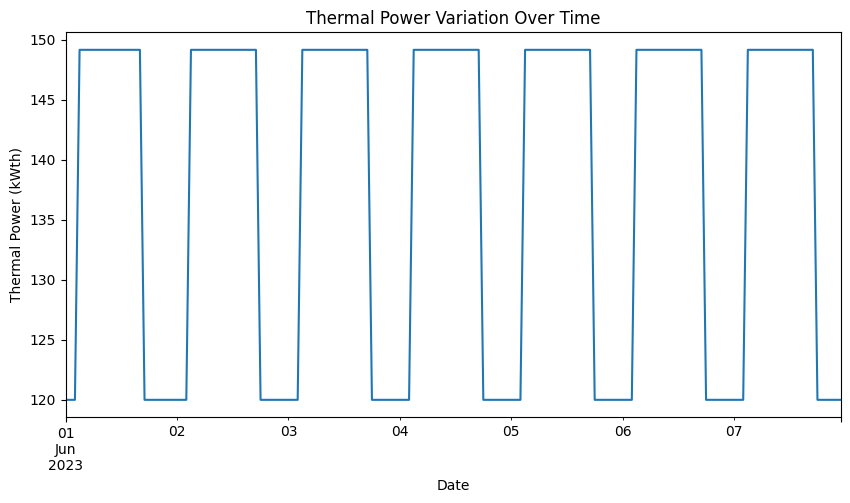

In [5]:
if params.get("data_filename", None) is None:
    # Convert dictionaries to Series indexed by date
    sunrise_series = pd.Series(sunrise_times).dt.tz_convert('UTC')
    sunset_series = pd.Series(sunset_times).dt.tz_convert('UTC')

    # Initialize thermal load series (default to Pn)
    Q = pd.Series(params["Q_nominal"], index=date_rng, dtype=float)
    Tv = pd.Series(params["Tv_nominal"], index=date_rng, dtype=float)

    # Ensure the index of Q aligns with the datetime range
    date_index = Q.index

    # Get the sunrise and sunset times for each timestamp
    sunrise_match = sunrise_series.reindex(date_index.date, method="ffill").values
    sunset_match = sunset_series.reindex(date_index.date, method="ffill").values

    # Create a Boolean mask where the condition is met
    if params.get("partial_at_night", False):
        # Night-time
        mask = (date_index.values <= sunrise_match) | (date_index.values >= sunset_match)
    else:
        # Daytime
        mask = (date_index.values >= sunrise_match) & (date_index.values <= sunset_match)
        
    # Update Q using vectorized assignment
    if params.get("Q_partial", None) is not None:
        Q.loc[mask] = params["Q_partial"]
    if params.get("Tv_partial", None) is not None:
        Tv.loc[mask] = params["Tv_partial"]

    # Plot the results
    plt.figure(figsize=(10, 5))
    Q['2023-06-01':'2023-06-07'].plot()
    plt.xlabel("Date")
    plt.ylabel("Thermal Power (kWth)")
    plt.title("Thermal Power Variation Over Time")
    plt.show()


In [6]:
if params.get("data_filename", None) is None:
    # Vapor mass flow rate, extremely slow
    mv = np.array(
        [pth / (w_props(T=tv+273.15, x=1).h - w_props(T=tv+273.15, x=0).h) * 3600 for pth, tv in zip(Q, Tv)] # kg/h
    )


In [7]:
if params.get("data_filename", None) is None:

    df_load = pd.DataFrame({'Q_kW': Q, 'Tv_C': Tv, 'mv_kgh': mv})

    logger.info(f"Resulting dataframe has {len(df_load)} rows")

    # Save to hdf5 and csv
    fname = f"thermal_load_data_{environment_id}_{df_load.index[0].strftime('%Y%m%d')}_{df_load.index[-1].strftime('%Y%m%d')}"
    df_load.sort_index(inplace=True)
    df_load.to_hdf(data_path / f"{fname}.h5", key="data", mode="w", format="table")
    df_load.to_csv(data_path / f"{fname}.csv")
        
    logger.info(f"Saved {fname} to {data_path}")

    df_load


2025-04-15 09:49:00.804 | INFO     | __main__:<module>:5 - Resulting dataframe has 26304 rows


2025-04-15 09:49:01.047 | INFO     | __main__:<module>:13 - Saved thermal_load_data_med_eds_20220101_20241231 to ../../data/datasets/partial


In [8]:
df = pd.read_hdf(data_path / f"{fname}.h5", index_col=0, parse_dates=True)
df


,Q_kW,Tv_C,mv_kgh
2022-01-01 00:00:00+00:00,120.0,36.7,178.964574
2022-01-01 01:00:00+00:00,120.0,36.7,178.964574
2022-01-01 02:00:00+00:00,120.0,36.7,178.964574
2022-01-01 03:00:00+00:00,120.0,36.7,178.964574
2022-01-01 04:00:00+00:00,120.0,36.7,178.964574
...,...,...,...
2024-12-31 19:00:00+00:00,120.0,36.7,178.964574
2024-12-31 20:00:00+00:00,120.0,36.7,178.964574
2024-12-31 21:00:00+00:00,120.0,36.7,178.964574
2024-12-31 22:00:00+00:00,120.0,36.7,178.964574


In [9]:
# Visualize data
from plotly_resampler import FigureWidgetResampler
from plotly.subplots import make_subplots
import plotly.graph_objects as go

var_ids: list[str] = ["Q_kW", "Tv_C", "mv_kgh"]
var_units: list[str] = [r"kW<sub>th</sub>", "°C", "kg/h"]

fig = make_subplots(rows=len(var_ids), cols=1, shared_xaxes=True)
fig = FigureWidgetResampler(fig)

for i, (var_id, var_unit) in enumerate(zip(var_ids, var_units)):
    fig.add_trace(
        go.Scattergl(name=var_id, showlegend=True), 
        hf_x=df.index, 
        hf_y=np.ascontiguousarray(df[var_id]), 
        # max_n_samples=2_000,
        row=i + 1, col=1
    )
    fig.update_yaxes(title_text=f"{var_id.replace("_", " ")} ({var_unit})", row=i + 1)

fig.update_layout(
    height=650,
    width=800,
    title="<b>Thermal load</b>",
    title_x=0.1,
    legend_traceorder="normal",
    legend=dict(orientation="h", y=1.08, xanchor="left", x=0),
)

fig


FigureWidgetResampler({
    'data': [{'name': '<b style="color:sandybrown">[R]</b> Q_kW <i style="color:#fc9944">~1D</i>',
              'showlegend': True,
              'type': 'scattergl',
              'uid': '9be2ac5e-63f4-4a8e-9743-3e8753a89e92',
              'x': array([datetime.datetime(2022, 1, 1, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 1, 6, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 2, 4, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2024, 12, 30, 6, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 30, 16, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 31, 23, 0, tzinfo=datetime.timezone.utc)],
                         shape=(1000,), dtype=object),
              'xaxis': 'x',
              'y': array([120.        , 149.15692604, 120.        , ..., 149.15692604,
     

In [ ]:
from phd_visualizations import save_figure

if fig.layout.xaxis.range is not None:
    start, end = fig.layout.xaxis.range
else:
    start, end = df.index[0].strftime("%Y-%m-%d %H:%M:%S.%f")[:-2], df.index[-1].strftime("%Y-%m-%d %H:%M:%S.%f")[:-2]
    
save_figure(fig, f"solhycool_thermal_load_viz_{start[:10].replace('-', '')}_{end[:10].replace('-', '')}", 
            figure_path=viz_output_path, formats=["png", "svg"])


2025-04-15 09:49:05.216 | INFO     | phd_visualizations:save_figure:38 - Figure saved in [PosixPath('../results')]/solhycool_thermal_load_viz_20220101_20241231.png
2025-04-15 09:49:07.440 | INFO     | phd_visualizations:save_figure:38 - Figure saved in [PosixPath('../results')]/solhycool_thermal_load_viz_20220101_20241231.svg
